In [1]:
import joblib
import cloudpickle
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

import pymc as pm
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Arc

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)

In [2]:
print(pm.__version__)

5.25.1


In [3]:
bart_mm_scaler = joblib.load('minmax_scaler.pkl')

In [4]:
df=pd.read_csv('input/full_results.csv')
df['shot_type_idx'] = df['shot_type'].map({'JUMPER': 0, 'LAYUP': 1, 'HOOK': 2, 'DUNK': 3})
df['sub_type_idx'] = df['subType_idx'] - 1
df['season_idx'] = df['season_idx'] - 1
df = df.loc[df['period']<=4].reset_index(drop=True)
df['PLAYER_ID'] = pd.to_numeric(df['PLAYER_ID'], errors='coerce')
df = df.dropna(subset=['PLAYER_ID'])
df.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train,distance_mm,angle_mm,probs,baseline_logit,logit_sd,sub_type_idx
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,0,2022-23,0,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1,0.267300,0.670484,0.428531,-0.288581,0.103031,0
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,0,2022-23,0,Marcus Smart,203935.0,29.401780,76.0,G,2,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1,0.275325,0.653883,0.427449,-0.292989,0.101178,1
2,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,1,2022-23,0,Tobias Harris,202699.0,31.041752,79.0,F,3,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1,0.000000,0.000000,0.697259,0.841187,0.188602,3
3,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,0,2022-23,0,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1,0.494566,0.780882,0.384304,-0.472442,0.098655,4
4,22200001,6,17,23,MISS Maxey 4' Driving Layup,0,3.883298,78.111342,38,8,2,Driving Layup Shot,6,LAYUP,1,2022-23,0,Tyrese Maxey,1630178.0,22.735113,74.0,G,2,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,2.0,5.0,-3.0,1,10.200000,612.0,0,1610612755,PHI,1,0.080995,0.781255,0.487208,-0.051393,0.135053,5


In [5]:
target=df['is_made'].values
df.shape

(497034, 47)

In [6]:
def sample(
    model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED
):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            cores=4,
            idata_kwargs={"log_likelihood": False}
        )
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [7]:
shot_type_idx_vals = df['shot_type_idx'].values
baseline_logit_vals = df['baseline_logit'].values
season_idx_vals = df['season_idx'].values

In [8]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":["JUMPER", "LAYUP", "HOOK", "DUNK"]
        
    }
with pm.Model(coords=coords) as model:
    # mutable data
    shot_made = pm.Data("shot_made", target, dims=("obs_id",))
    baseline_logits = pm.Data("baseline_logits", baseline_logit_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals.astype("int32"), dims=("obs_id",))
    # baseline
    baseline_weight = pm.Normal("baseline_weight", 1, 0.25)
    # shot type effect
    sigma_shot_type = pm.Exponential("sigma_shot_type", 1.0)
    shot_type_effect = pm.Normal("shot_type_effect", mu=0.0, sigma=sigma_shot_type, dims=("shot_type",))
    shot_type_contribution = shot_type_effect[shot_type_idx]
    # additive components
    theta = baseline_weight*baseline_logits + shot_type_contribution
    shot_lkhood = pm.Bernoulli("shot_lkhood", logit_p=theta, observed=shot_made, dims=("obs_id",))

In [9]:
trace = sample(model, tune=1500, draws=1500, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [baseline_weight, sigma_shot_type, shot_type_effect]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 644 seconds.


In [10]:
az.to_netcdf(trace, 'trace_objects/shottype.nc')

'trace_objects/shottype.nc'

In [11]:
with open("models_pkl/shot_type.pkl", "wb") as f:
    cloudpickle.dump(model, f)

In [ ]:
#trace = az.from_netcdf('trace_objects/shottype.nc')

In [ ]:
# with open("models_pkl/shot_type.pkl", "rb") as f:
#     model = cloudpickle.load(f)

In [12]:
az.summary(
    trace,
    var_names=[
        "baseline_weight",
        "sigma_shot_type",
        "shot_type_effect"
        ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
baseline_weight,1.037,0.010,1.018,1.057,0.000,0.000,2877.0,3251.0,1.0
sigma_shot_type,0.805,0.350,0.359,1.415,0.006,0.012,4595.0,3338.0,1.0
shot_type_effect[JUMPER],0.021,0.006,0.011,0.032,0.000,0.000,3016.0,3189.0,1.0
shot_type_effect[LAYUP],-0.204,0.007,-0.217,-0.191,0.000,0.000,3738.0,3962.0,1.0
shot_type_effect[HOOK],0.019,0.017,-0.011,0.050,0.000,0.000,4939.0,4274.0,1.0
shot_type_effect[DUNK],1.279,0.020,1.244,1.319,0.000,0.000,4643.0,4490.0,1.0


In [13]:
compute_log_likelihood(model, trace)

Output()

In [14]:
az.loo(trace, var_name='shot_lkhood')

Computed from 6000 posterior samples and 497034 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -321218.89   199.82
p_loo        5.04        -
------

Pareto k diagnostic values:
                          Count   Pct.
(-Inf, 0.70]   (good)     497034  100.0%
   (0.70, 1]   (bad)           0    0.0%
   (1, Inf)   (very bad)      0    0.0%

In [15]:
spp = sample_posterior_pred(model, trace)

Sampling: [shot_lkhood]


Output()

<Axes: xlabel='shot_lkhood'>

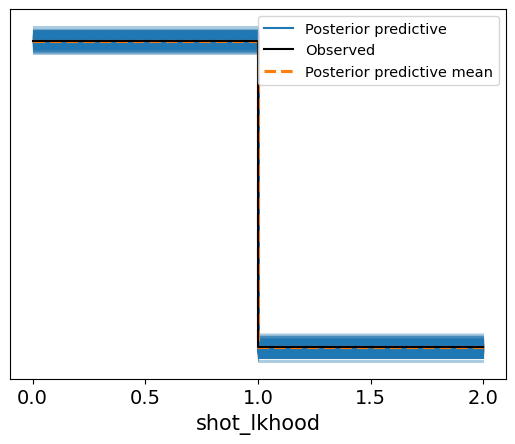

In [16]:
az.plot_ppc(spp, var_names='shot_lkhood', num_pp_samples=1000,random_seed=RANDOM_SEED)

In [17]:
del spp

<Axes: >

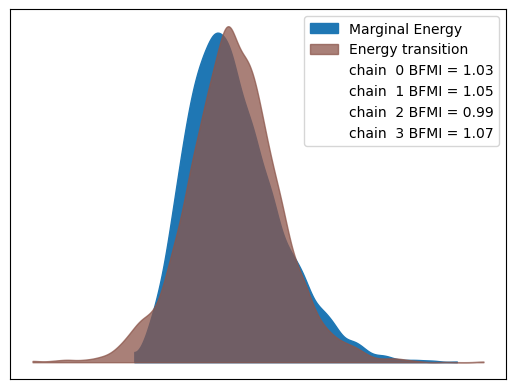

In [18]:
az.plot_energy(trace)

In [19]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

In [20]:
from scipy.special import expit
from tqdm import tqdm
baseline_weight  = trace.posterior["baseline_weight"].values
shot_type_effect = trace.posterior["shot_type_effect"].values

shot_type_contribution = shot_type_effect[:, :, shot_type_idx_vals]

In [21]:
def compute_theta(baseline_weight, shot_type_contribution, batch_size=5000):
    n_obs = shot_type_contribution.shape[2]
    batches = np.arange(0, n_obs, batch_size)

    logits_mean_list = []
    logits_sd_list = []
    probs_mean_list  = []

    for start in tqdm(batches):
        end = min(start + batch_size, n_obs)
        baseline_logit_batch = baseline_weight[:, :, None] * baseline_logit_vals[None, None, start:end]
        shot_type_contra_batch = shot_type_contribution[:, :, start:end]
        
        logits = baseline_logit_batch + shot_type_contra_batch
        probs = expit(logits)
        logits_mean = logits.mean(axis=(0, 1))
        logits_mean_list.append(logits_mean)
        probs_mean_list.append(probs.mean(axis=(0, 1)))
        logits_sd_list.append(logits.std(axis=(0, 1)))

        del logits, probs, baseline_logit_batch, shot_type_contra_batch

    return {
        "logits":     np.concatenate(logits_mean_list),
        "probs":      np.concatenate(probs_mean_list),
        "logits_sd":  np.concatenate(logits_sd_list)
    }

In [22]:
results = compute_theta(
    baseline_weight,
    shot_type_contribution,
    )

100%|██████████| 100/100 [00:29<00:00,  3.37it/s]


In [23]:
train_score = compute_scores(target, results['probs'])
print("Train Log Loss:", train_score[0])
print("Train AUC:", train_score[1])
print("Train Accuracy:", train_score[2])

Train Log Loss: 0.6462613232911116
Train AUC: 0.6453505344384612
Train Accuracy: 0.6220982870387136
